In [23]:
import numpy as np
import pandas as pd

In [24]:
df = pd.read_csv("Admission_Predict_Ver1.1.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [25]:
df.shape

(500, 9)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [27]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [28]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#remove unnecessary columns
df.drop('Serial No.', axis=1, inplace=True)

In [30]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [31]:
X=df.iloc[:,0:-1] #all rows,cols from 0 to -1 but -1 ie last col not inc
y=df.iloc[:,-1] #all rows and -1 (last) column

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [32]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
238,310,104,3,2.0,3.5,8.37,0
438,318,110,1,2.5,3.5,8.54,1
475,300,101,3,3.5,2.5,7.88,0
58,300,99,1,3.0,2.0,6.80,1
380,322,104,3,3.5,4.0,8.84,1
...,...,...,...,...,...,...,...
255,307,110,4,4.0,4.5,8.37,0
72,321,111,5,5.0,5.0,9.45,1
396,325,107,3,3.0,3.5,9.11,1
235,326,111,5,4.5,4.0,9.23,1


In [33]:
#fit() → learn mean & standard deviation
#transform() → apply scaling

#using minmax scaler because we know upper bound and lower bound
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()


X_train_trf = scaler.fit_transform(X_train)

#Only transform, not fit again so that it learns from training data and applies on test data
X_test_trf = scaler.transform(X_test)

In [34]:
X_train_trf

array([[0.4       , 0.42857143, 0.5       , ..., 0.57142857, 0.50320513,
        0.        ],
       [0.56      , 0.64285714, 0.        , ..., 0.57142857, 0.55769231,
        1.        ],
       [0.2       , 0.32142857, 0.5       , ..., 0.28571429, 0.34615385,
        0.        ],
       ...,
       [0.7       , 0.53571429, 0.5       , ..., 0.57142857, 0.74038462,
        1.        ],
       [0.72      , 0.67857143, 1.        , ..., 0.71428571, 0.77884615,
        1.        ],
       [0.2       , 0.46428571, 0.        , ..., 0.14285714, 0.32051282,
        0.        ]], shape=(400, 7))

In [35]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [45]:
model = Sequential()
#input layer (7 rows) 
model.add(Dense(7,activation='relu',input_dim=7))
#hidden layer
model.add(Dense(7,activation='relu'))
#output layer
model.add(Dense(1,activation='linear'))

c:\Users\VAISHNAVI\anaconda3\envs\notebook\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
#compile model (loss func help to minimize loss)
model.compile(optimizer='Adam',loss='mean_squared_error',metrics=['accuracy'])

In [48]:
#model fit
history = model.fit(X_train_trf,y_train,epochs=50,validation_split=0.2)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.0000e+00 - loss: 0.1933 - val_accuracy: 0.0000e+00 - val_loss: 0.1676
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 0.1303 - val_accuracy: 0.0000e+00 - val_loss: 0.1175
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 0.0912 - val_accuracy: 0.0000e+00 - val_loss: 0.0971
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: 0.0757 - val_accuracy: 0.0000e+00 - val_loss: 0.0882
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 0.0652 - val_accuracy: 0.0000e+00 - val_loss: 0.0779
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: 0.0568 - val_accuracy: 0.0000e+00 - val_loss: 0.0663
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 0.0481 - val_accuracy: 0.0000e+00 - val_loss: 0.0555
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy:

In [49]:
#make predictions on test data
y_pred=model.predict(X_test_trf)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([[0.6917598 ],
       [0.6799049 ],
       [0.95495486],
       [0.7279576 ],
       [0.8129705 ],
       [0.6663139 ],
       [0.7637423 ],
       [0.73700714],
       [0.8179265 ],
       [0.7097585 ],
       [0.6882745 ],
       [0.5777477 ],
       [0.7739988 ],
       [0.8321104 ],
       [0.78300214],
       [0.8251965 ],
       [0.6208222 ],
       [0.7516742 ],
       [0.9089358 ],
       [0.6922854 ],
       [0.6151616 ],
       [0.75211287],
       [0.8314891 ],
       [0.5785084 ],
       [0.79827565],
       [0.6185328 ],
       [0.91805506],
       [0.6489341 ],
       [0.8520937 ],
       [0.67750174],
       [0.62452924],
       [0.82427466],
       [0.5808865 ],
       [0.91172886],
       [0.58579016],
       [0.79834723],
       [0.6970064 ],
       [0.65308416],
       [0.67706215],
       [0.9384179 ],
       [0.5697798 ],
       [0.6640898 ],
       [0.7188997 ],
       [0.9654714 ],
       [0.76198035],
       [0.53096676],
       [0.67773795],
       [0.646

In [50]:
#y test is actual data and y pred is our prediction
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7864785590283094

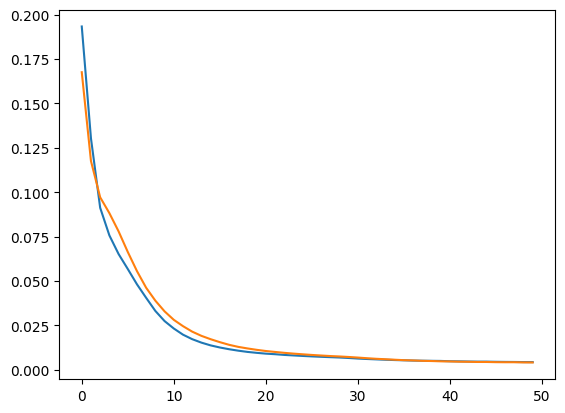

In [51]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

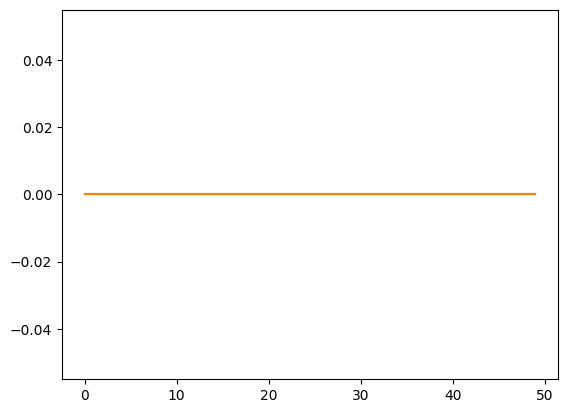

In [52]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])